<a href="https://colab.research.google.com/github/cassianvasc/Analise-de-dados-telas-criancas/blob/main/ScreenTime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install kagglehub


In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "screen_time.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "ak0212/average-daily-screen-time-for-children",
  file_path,
  )

print("First 5 records:", df.head())

/tmp/ipykernel_2358/760630884.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 8.15k/8.15k [00:00<00:00, 11.7MB/s]

First 5 records:    Age Gender Screen Time Type Day Type  Average Screen Time (hours)  \
0    5   Male      Educational  Weekday                         0.44   
1    5   Male     Recreational  Weekday                         1.11   
2    5   Male            Total  Weekday                         1.55   
3    5   Male      Educational  Weekend                         0.50   
4    5   Male     Recreational  Weekend                         1.44   

   Sample Size  
0          500  
1          500  
2          500  
3          500  
4          500  


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          198 non-null    int64  
 1   Gender                       198 non-null    object 
 2   Screen Time Type             198 non-null    object 
 3   Day Type                     198 non-null    object 
 4   Average Screen Time (hours)  198 non-null    float64
 5   Sample Size                  198 non-null    int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 9.4+ KB


In [5]:
df.Age.mean()

np.float64(10.0)

In [6]:
df.Age.median()

10.0

In [7]:
df.Age.mode()

,Age
0,5
1,6
2,7
3,8
4,9
5,10
6,11
7,12
8,13
9,14


In [8]:
df.describe()

,Age,Average Screen Time (hours),Sample Size
count,198.000000,198.000000,198.000000
mean,10.000000,2.993030,400.000000
std,3.170294,1.922822,63.405872
min,5.000000,0.440000,300.000000
25%,7.000000,1.402500,340.000000
50%,10.000000,2.490000,400.000000
75%,13.000000,4.397500,460.000000
max,15.000000,8.190000,500.000000


In [9]:
df.Age.quantile(q=[0.25,0.50,0.75])

,Age
0.25,7.0
0.50,10.0
0.75,13.0


In [10]:
import pandas as pd
import numpy as np
import scipy
import seaborn as sns
import matplotlib.pyplot as plt

(array([18., 18., 18., 18., 18., 18., 18., 18., 18., 36.]),
 array([ 5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14., 15.]),
 <BarContainer object of 10 artists>)

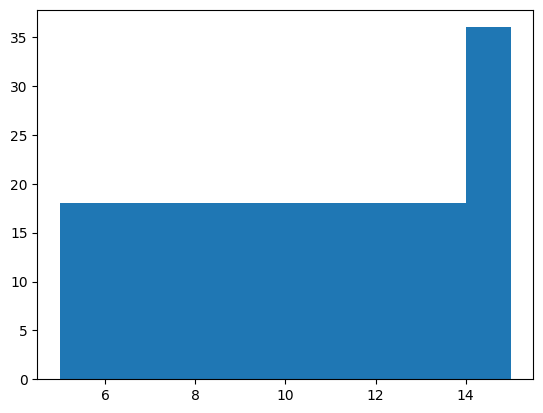

In [11]:
plt.hist(df.Age)

<Axes: xlabel='Age', ylabel='Density'>

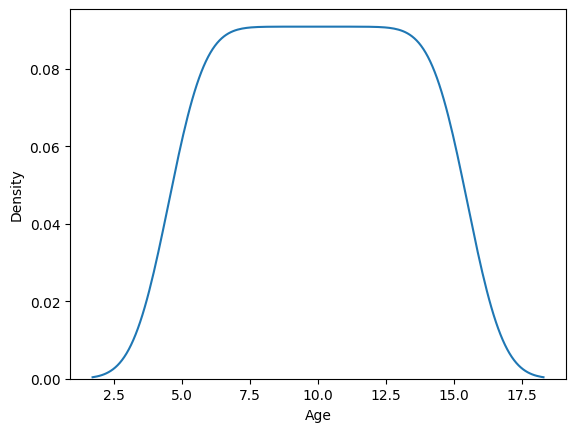

In [12]:
sns.kdeplot(df.Age)

<Axes: ylabel='Age'>

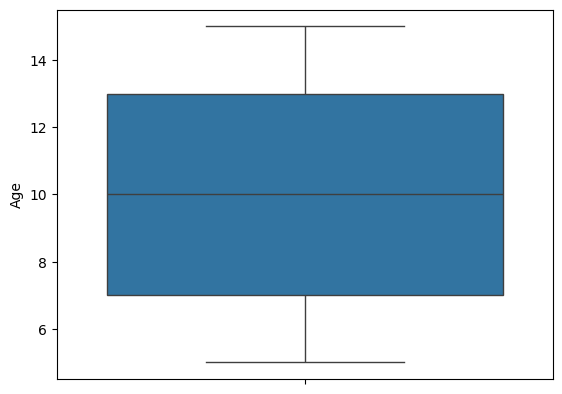

In [13]:
sns.boxplot(y=df.Age)

In [14]:
#Tratamento de dados nulos
df.isnull().sum()

,0
Age,0
Gender,0
Screen Time Type,0
Day Type,0
Average Screen Time (hours),0
Sample Size,0


In [16]:
#codificação de strings
df.select_dtypes(include="object").columns

# A coluna "Day Type" foi codificada com Laben Encode
df["Day Type"] = df["Day Type"].map({
    "Weekday": 0,
    "Weekend": 1
})

# Para as demais colunas foi utilizado o One-Hot Encode
df = pd.get_dummies(
    df,
    columns=[
        "Gender",
        "Screen Time Type"
    ],
    dtype=int
)

print(df.head())

   Age  Day Type  Average Screen Time (hours)  Sample Size  Gender_Female  \
0    5         0                         0.44          500              0   
1    5         0                         1.11          500              0   
2    5         0                         1.55          500              0   
3    5         1                         0.50          500              0   
4    5         1                         1.44          500              0   

   Gender_Male  Gender_Other/Prefer not to say  Screen Time Type_Educational  \
0            1                               0                             1   
1            1                               0                             0   
2            1                               0                             0   
3            1                               0                             1   
4            1                               0                             0   

   Screen Time Type_Recreational  Screen Time Type_Total

In [21]:
#Normalização Min Max
colunas = [
    "Age",
    "Average Screen Time (hours)"
]

# Normalização Min-Max
df[colunas] = (df[colunas] - df[colunas].min()) / (df[colunas].max() - df[colunas].min())
df.head()


,Age,Day Type,Average Screen Time (hours),Sample Size,Gender_Female,Gender_Male,Gender_Other/Prefer not to say,Screen Time Type_Educational,Screen Time Type_Recreational,Screen Time Type_Total
0,0.0,0,0.000000,1.0,0,1,0,1,0,0
1,0.0,0,0.086452,1.0,0,1,0,0,1,0
2,0.0,0,0.143226,1.0,0,1,0,0,0,1
3,0.0,1,0.007742,1.0,0,1,0,1,0,0
4,0.0,1,0.129032,1.0,0,1,0,0,1,0


In [22]:
#Análise de outliers
colunas = [
    "Age",
    "Average Screen Time (hours)",
    "Sample Size"
]
for coluna in colunas:
    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]

    print(coluna)
    print("outliers:", len(outliers))
    print()

Age
outliers: 0

Average Screen Time (hours)
outliers: 0

Sample Size
outliers: 0

